### Fade Margin (FM) Section — Calibrate on OOF, Validate on Test

This notebook calibrates fade margins (FM) for COST 231 MWM, MLR, kNN, RF, LightGBM, XGBoost, and ANN using Out-Of-Fold (OOF) residuals and validates them on the held-out test residuals.


#### Core & Data Libraries

In [1]:
# Standard library
import os
import pickle
import time
from pathlib import Path

# Thread control: set before NumPy/SciPy/sklearn imports
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["NUMEXPR_MAX_THREADS"] = "1"

if os.path.isdir("/dev/shm"):
    os.environ.setdefault("JOBLIB_TEMP_FOLDER", "/dev/shm/joblib")

# Data and numerical computing
import numpy as np
import pandas as pd
import scipy.stats as sps

# Modeling and parallelism
from sklearn.mixture import GaussianMixture
from joblib import Parallel, delayed

# Plotting
import matplotlib.pyplot as plt


from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score

# Notebook display
from IPython.display import display

# Parallelism
N_JOBS = -1

# Global toggles
EXACT_BCA = False
BLOCK_BY_DEVICE = True
RANDOM_STATE = 42

# Fade-margin settings
P_GRID = [0.05, 0.02, 0.01]
HEURISTIC_FM_DB = 10.0
BOOTSTRAP_B = 1000

#### Load OOF Residuals

In [2]:
# Data locations
OOF_DIR  = "Residuals"
TEST_DIR = "Residuals"

# Candidate mappings (OOF)
CANDIDATE_OOF_FILES = {
    "MLR":      [f"{OOF_DIR}/residuals_MLR_oof.csv"],
    "COST 231 MWM": [f"{OOF_DIR}/residuals_PLM_COST231_MWM_oof.csv"],
    "KNN":      [f"{OOF_DIR}/residuals_KNN_oof.csv"],
    "RF":       [f"{OOF_DIR}/residuals_RF_oof.csv"],
    "LightGBM": [f"{OOF_DIR}/residuals_LGBM_oof.csv"],
    "XGBoost":  [f"{OOF_DIR}/residuals_XGB_oof.csv"],
    "ANN":      [f"{OOF_DIR}/residuals_ANN_oof.csv"],
}

# Candidate mappings (held-out test)
CANDIDATE_TEST_FILES = {
    "MLR":      [f"{TEST_DIR}/residuals_MLR_test.csv"],
    "COST 231 MWM": [f"{TEST_DIR}/residuals_PLM_COST231_MWM_test.csv"],
    "KNN":      [f"{TEST_DIR}/residuals_KNN_test.csv"],
    "RF":       [f"{TEST_DIR}/residuals_RF_test.csv"],
    "LightGBM": [f"{TEST_DIR}/residuals_LGBM_test.csv"],
    "XGBoost":  [f"{TEST_DIR}/residuals_XGB_test.csv"],
    "ANN":      [f"{TEST_DIR}/residuals_ANN_test.csv"],
}

MODEL_ORDER = list(CANDIDATE_OOF_FILES.keys())

missing_test_mappings = sorted(set(CANDIDATE_OOF_FILES) - set(CANDIDATE_TEST_FILES))
if missing_test_mappings:
    raise KeyError(f"Missing held-out test residual mapping(s): {missing_test_mappings}")

# Column detection candidates
TIME_COL_CANDS   = ["timestamp", "ts", "time", "datetime", "DateTime", "TIME"]
DEVICE_COL_CANDS = ["device_id", "device", "Device", "ed", "ED", "node", "Node"]
RESID_COL_CANDS  = ["resid_db", "residuals", "resid", "error", "epsilon"]

def _first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    raise FileNotFoundError("None of the candidate paths exist:\\n  " + "\\n  ".join(paths))

def _pick_residual_col(df):
    for c in RESID_COL_CANDS:
        if c in df.columns:
            return c
    raise KeyError("Residual column not found in dataframe.")

def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _time_sort(df):
    tc = _find_col(df, TIME_COL_CANDS)
    if tc is None:
        return df
    try:
        return df.sort_values(tc)
    except Exception:
        tmp = pd.to_datetime(df[tc], errors="coerce")
        return df.assign(_t=tmp).sort_values("_t").drop(columns=["_t"])

# Load OOF calibration residuals and matching held-out test residuals.
oof_residuals = {}     # model -> np.array
test_residuals = {}    # model -> np.array
oof_devices   = {}     # model -> device array or None
test_devices  = {}     # model -> device array or None
model_tags    = {}     # model -> tag from 'model' column if present

for fam, candidates in CANDIDATE_OOF_FILES.items():
    oof_path = _first_existing(candidates)
    df_oof = _time_sort(pd.read_csv(oof_path))
    res_col = _pick_residual_col(df_oof)
    eps_oof = df_oof[res_col].astype(float).to_numpy()
    oof_residuals[fam] = eps_oof

    dev_col_oof = _find_col(df_oof, DEVICE_COL_CANDS)
    oof_devices[fam] = df_oof[dev_col_oof].astype(str).to_numpy() if dev_col_oof else None

    if "model" in df_oof.columns and len(df_oof):
        model_tags[fam] = str(df_oof["model"].iloc[0])
    else:
        model_tags[fam] = fam

    test_path = _first_existing(CANDIDATE_TEST_FILES[fam])
    df_test = _time_sort(pd.read_csv(test_path))
    res_col_test = _pick_residual_col(df_test)
    eps_test = df_test[res_col_test].astype(float).to_numpy()
    test_residuals[fam] = eps_test

    dev_col_test = _find_col(df_test, DEVICE_COL_CANDS)
    test_devices[fam] = df_test[dev_col_test].astype(str).to_numpy() if dev_col_test else None

    print(f"[{fam}] OOF: {oof_path} (n={len(eps_oof)}) | TEST: {test_path} (n={len(eps_test)})")

[MLR] OOF: Residuals/residuals_MLR_oof.csv (n=1773515) | TEST: Residuals/residuals_MLR_test.csv (n=532055)


[COST 231 MWM] OOF: Residuals/residuals_PLM_COST231_MWM_oof.csv (n=1773515) | TEST: Residuals/residuals_PLM_COST231_MWM_test.csv (n=532055)


[KNN] OOF: Residuals/residuals_KNN_oof.csv (n=1773515) | TEST: Residuals/residuals_KNN_test.csv (n=532055)


[RF] OOF: Residuals/residuals_RF_oof.csv (n=1773515) | TEST: Residuals/residuals_RF_test.csv (n=532055)


[LightGBM] OOF: Residuals/residuals_LGBM_oof.csv (n=1773515) | TEST: Residuals/residuals_LGBM_test.csv (n=532055)


[XGBoost] OOF: Residuals/residuals_XGB_oof.csv (n=1773515) | TEST: Residuals/residuals_XGB_test.csv (n=532055)


[ANN] OOF: Residuals/residuals_ANN_oof.csv (n=1773515) | TEST: Residuals/residuals_ANN_test.csv (n=532055)


#### FM Calibration Utilities

In [3]:
# ACF / block length utilities
def acf(x, max_lag=None):
    x = np.asarray(x, float)
    x = x - x.mean()
    n = len(x)
    if n < 3:
        max_lag = 1
    if max_lag is None:
        max_lag = min(200, n - 2) if n > 2 else 1
    c = np.correlate(x, x, mode='full')[n-1:n+max_lag]
    if c[0] == 0:
        return np.arange(max_lag+1), np.ones(max_lag+1)
    return np.arange(max_lag+1), c / c[0]

def choose_block_len_acf(x, alpha=0.05, max_lag=None):
    lags, ac = acf(x, max_lag=max_lag)
    n = len(x)
    if n < 50:
        return 0, {"note": "sample too small; using i.i.d."}
    thr = 1.96 / np.sqrt(n)  # ~95% bounds
    idx = np.where(np.abs(ac[1:]) < thr)[0]
    if len(idx) == 0:
        k = min(len(ac)-1, 25)
    else:
        k = int(idx[0] + 1)
    b = max(5, k)
    return b, {"thr": thr, "first_below_thr_lag": k}

def choose_block_len_acf_cluster(x, clust):
    """Median block length across clusters (skip very small ones)."""
    x = np.asarray(x)
    clust = np.asarray(clust) if clust is not None else None
    if clust is None:
        b, _ = choose_block_len_acf(x)
        return b
    b_list = []
    for g in np.unique(clust):
        idx = (clust == g)
        if idx.sum() < 50:  # insufficient for ACF estimate
            continue
        b_g, _ = choose_block_len_acf(x[idx])
        b_list.append(b_g)
    if not b_list:
        return 0
    return int(np.median(b_list))

def _mbb_draw(x, n, b, rng):
    """Moving-block bootstrap draw of length n from series x with block size b."""
    x = np.asarray(x)
    if b <= 1 or b >= len(x):
        return x[rng.integers(0, len(x), size=n)]
    k = int(np.ceil(n / b))
    starts = rng.integers(0, len(x) - b + 1, size=k)
    return np.concatenate([x[s:s+b] for s in starts])[:n]

def _mbb_draw_by_cluster(x, clust, b, rng):
    """MBB within device clusters; preserves per-device lengths."""
    x = np.asarray(x)
    clust = np.asarray(clust)
    out = []
    for g in np.unique(clust):
        idx = np.where(clust == g)[0]
        xx = x[idx]
        n_g = len(xx)
        out.append(_mbb_draw(xx, n_g, b, rng))
    return np.concatenate(out)

#  quantile utilities 
def normal_cdf(z):
    z = np.asarray(z, dtype=float)
    return sps.norm.cdf(z)

def empirical_quantile(sample, p):
    # FM(p) = Q_{1-p} of residuals
    return float(np.quantile(sample, 1 - p, method='linear'))

def mixture_quantile(weights, means, stds, q, tol=1e-6, max_iter=256):
    means = np.asarray(means); stds = np.asarray(stds)
    stds = np.maximum(stds, 1e-6)  # guard against numeric degeneracy
    lo = float(means.min() - 10*stds.max())
    hi = float(means.max() + 10*stds.max())
    for _ in range(max_iter):
        mid = 0.5*(lo+hi)
        F = float(np.sum(weights * normal_cdf((mid - means)/stds)))
        if F < q: lo = mid
        else:     hi = mid
        if hi - lo < tol: break
    return 0.5*(lo+hi)

#  fixed K=3 mixture fit + tail quantile 
def gmm_fit_quantile(sample, p, n_components=3):
    """
    Fit a 1D GaussianMixture with fixed n_components=3 and return Q_{1-p} of the fitted mixture.
    """
    xs = sample.reshape(-1, 1)
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=RANDOM_STATE)
    gmm.fit(xs)
    w = gmm.weights_
    mu = gmm.means_.ravel()
    cov = gmm.covariances_
    stds = np.sqrt(cov.reshape(-1)) if cov.ndim == 3 else np.sqrt(cov)
    q = mixture_quantile(w, mu, stds, 1 - p)
    aic = float(gmm.aic(xs))
    bic = float(gmm.bic(xs))
    return float(q), {"gmm": gmm, "k": n_components}, aic, bic

#  Nonparametric CIs for empirical quantiles 
def bca_ci(x, stat_fn, alpha=0.05, B=10_000, block_len=0, rng=None, cluster=None):
    """
    Exact BCa CI for statistic stat_fn over sample x.
    Uses MBB if block_len>0; device-aware if cluster provided and BLOCK_BY_DEVICE=True.
    """
    rng = np.random.default_rng(RANDOM_STATE if rng is None else rng)
    x = np.asarray(x)
    n = len(x)
    theta_hat = stat_fn(x)

    # bootstrap replicates (serial to keep jackknife coherent)
    thetas = np.empty(B, dtype=float)
    ss = np.random.SeedSequence(RANDOM_STATE)
    children = ss.spawn(B)
    for b in range(B):
        rr = np.random.default_rng(children[b])
        if block_len > 1:
            if (cluster is not None) and BLOCK_BY_DEVICE:
                xb = _mbb_draw_by_cluster(x, cluster, block_len, rr)
            else:
                xb = _mbb_draw(x, n, block_len, rr)
        else:
            xb = x[rr.integers(0, n, size=n)]
        thetas[b] = stat_fn(xb)
    thetas.sort()

    # bias-correction z0
    z0 = sps.norm.ppf((thetas < theta_hat).mean() + 1e-12)

    # jackknife for acceleration 'a'
    jack = np.empty(n)
    for i in range(n):
        jack[i] = stat_fn(np.delete(x, i))
    jack_mean = jack.mean()
    num = np.sum((jack_mean - jack)**3)
    den = 6.0 * (np.sum((jack_mean - jack)**2) ** 1.5)
    a = (num / den) if den > 0 else 0.0

    zal = sps.norm.ppf(alpha/2); zau = sps.norm.ppf(1 - alpha/2)
    def _adj(z): return sps.norm.cdf(z0 + (z0 + z) / (1 - a*(z0 + z)))
    a1 = float(np.clip(_adj(zal), 0, 1)); a2 = float(np.clip(_adj(zau), 0, 1))

    lo = float(np.quantile(thetas, a1, method='linear'))
    hi = float(np.quantile(thetas, a2, method='linear'))
    return lo, hi, {"theta_hat": float(theta_hat), "z0": float(z0), "a": float(a)}

def _boot_q_once(x, p, b, sseq, cluster=None):
    rr = np.random.default_rng(sseq)
    if b > 1:
        if (cluster is not None) and BLOCK_BY_DEVICE:
            xb = _mbb_draw_by_cluster(x, cluster, b, rr)
        else:
            xb = _mbb_draw(x, len(x), b, rr)
    else:
        xb = x[rr.integers(0, len(x), size=len(x))]
    return float(np.quantile(xb, 1 - p, method='linear'))

def bc_ci_fast(x, p, alpha=0.05, B=3000, block_len=0, n_jobs=N_JOBS, seed=RANDOM_STATE, cluster=None):
    """
    Fast CI for FM(p)=Q_{1-p}:
    - Parallel bootstrap with MBB (b>0); device-aware if cluster provided.
    - Bias-Corrected (BC) via z0 (no jackknife).
    """
    x = np.asarray(x, float)
    theta_hat = float(np.quantile(x, 1 - p, method='linear'))

    ss = np.random.SeedSequence(seed)
    children = ss.spawn(B)

    q_boot = Parallel(n_jobs=n_jobs, backend="loky", max_nbytes="256M", verbose=0)(
        delayed(_boot_q_once)(x, p, block_len, child, cluster) for child in children
    )
    q_boot = np.asarray(q_boot, float)

    if q_boot.min() < theta_hat < q_boot.max():
        prop = (q_boot < theta_hat).mean()
        z0 = float(sps.norm.ppf(min(max(prop, 1e-12), 1 - 1e-12)))
        al = float(sps.norm.cdf(2*z0 + sps.norm.ppf(alpha/2)))
        au = float(sps.norm.cdf(2*z0 + sps.norm.ppf(1 - alpha/2)))
        al = float(np.clip(al, 0.0, 1.0)); au = float(np.clip(au, 0.0, 1.0))
    else:
        al, au = alpha/2, 1 - alpha/2

    lo, hi = np.quantile(q_boot, [al, au], method='linear')
    return float(lo), float(hi), {"theta_hat": theta_hat}

#  Parametric bootstrap CI for GMM-3 tail FM 
def _gmm_sample(n, weights, means, stds, rng):
    k = len(weights)
    comps = rng.choice(k, size=n, p=weights)
    return rng.normal(loc=means[comps], scale=stds[comps], size=n)

def gmm_parametric_ci(sample, p, gmm_obj, alpha=0.05, B=BOOTSTRAP_B, seed=RANDOM_STATE):
    """
    Parametric bootstrap CI for FM(p) under a fitted 1D Gaussian mixture.
    Draws length-n samples from the fitted mixture and re-computes Q_{1-p}.
    """
    n = len(sample)
    rng = np.random.default_rng(seed)
    w = gmm_obj.weights_
    mu = gmm_obj.means_.ravel()
    cov = gmm_obj.covariances_
    stds = np.sqrt(cov.reshape(-1)) if cov.ndim == 3 else np.sqrt(cov)

    theta_hat = mixture_quantile(w, mu, stds, 1 - p)

    qs = np.empty(B, dtype=float)
    for b in range(B):
        xs = _gmm_sample(n, w, mu, stds, rng)
        qs[b] = np.quantile(xs, 1 - p, method='linear')
    lo, hi = np.quantile(qs, [alpha/2, 1 - alpha/2], method='linear')
    return float(lo), float(hi), {"theta_hat_param": float(theta_hat)}

#  Main FM routine (GMM-3 only) 
def fm_with_uncertainty(eps, p, use_parametric=True, B=BOOTSTRAP_B, random_state=RANDOM_STATE, cluster=None, alpha=0.05):
    """
    Returns FM estimates and CIs.

    - Empirical FM always computed (with BCa or BC bootstrap CI).
    - If use_parametric=True, we fit a fixed 3-component GMM to eps, compute its tail FM and
      parametric-bootstrap CIs. For p <= 0.02, we prescribe the conservative maximum of
      the empirical and GMM-3 tail estimates; otherwise we keep the empirical FM.
    - The reported CI always brackets the selected FM: empirical CI for empirical rows,
      parametric CI for mixture rows.
    """
    eps = np.asarray(eps, float)

    # Dependence-aware block length (per cluster if available)
    block_len = choose_block_len_acf_cluster(eps, cluster)

    # Empirical quantile + CI
    if EXACT_BCA:
        lo_e, hi_e, info = bca_ci(
            eps,
            stat_fn=lambda v: float(np.quantile(v, 1 - p, method='linear')),
            alpha=alpha, B=B, block_len=block_len, rng=random_state, cluster=cluster
        )
        fm_emp = float(np.quantile(eps, 1 - p, method='linear'))
        note_emp = "empirical quantile (BCa)"
    else:
        lo_e, hi_e, info = bc_ci_fast(
            eps, p, alpha=alpha, B=B, block_len=block_len, n_jobs=N_JOBS, seed=random_state, cluster=cluster
        )
        fm_emp = info["theta_hat"]
        note_emp = "empirical quantile (BC bootstrap)"

    out = {
        "p": p, "block_len": block_len,
        "fm_emp": fm_emp, "fm_emp_lo": lo_e, "fm_emp_hi": hi_e,
        "param_name": None, "fm_param": np.nan, "param_lo": np.nan, "param_hi": np.nan,
        "param_aic": np.nan, "param_bic": np.nan,
        "selected": "empirical", "fm_sel": fm_emp, "fm_sel_lo": lo_e, "fm_sel_hi": hi_e,
        "estimator_note": note_emp
    }

    if use_parametric:
        fm_g, gmm_best, aic_g, bic_g = gmm_fit_quantile(eps, p, n_components=3)
        gmm_obj = gmm_best["gmm"]

        # Parametric-bootstrap CI around the mixture tail FM
        lo_p, hi_p, _ = gmm_parametric_ci(eps, p, gmm_obj, alpha=alpha, B=B, seed=random_state)

        out.update({
            "param_name": "gmm(K=3)",
            "fm_param": float(fm_g),
            "param_lo": float(lo_p), "param_hi": float(hi_p),
            "param_aic": float(aic_g), "param_bic": float(bic_g)
        })

        # Conservative switch at far tail if GMM-3 is larger than empirical
        if p <= 0.02 and (fm_g > fm_emp):
            out.update({
                "selected": "gmm-tail",
                "fm_sel": float(fm_g),
                "fm_sel_lo": float(lo_p), "fm_sel_hi": float(hi_p),
                "estimator_note": "gmm tail (K=3; parametric bootstrap CI)"
            })

    return out

#### Calibrate on OOF + Load Test Residuals

In [4]:
t0 = time.time()

rows = []
for fam in MODEL_ORDER:
    eps = oof_residuals[fam]
    for p in P_GRID:
        print(f"Calibrating {fam} at p={float(p):.2%}")
        out = fm_with_uncertainty(eps, p, use_parametric=True, B=BOOTSTRAP_B,
                                  random_state=RANDOM_STATE, cluster=oof_devices.get(fam))
        rows.append({"model": fam, **out})

fm_table = pd.DataFrame(rows)
fm_table["model"] = pd.Categorical(fm_table["model"], categories=MODEL_ORDER, ordered=True)
fm_table = fm_table.sort_values(["model", "p"]).reset_index(drop=True)
fm_table["model"] = fm_table["model"].astype(str)

display_cols = [
    "model", "p",
    "fm_emp", "fm_emp_lo", "fm_emp_hi",
    "param_name", "fm_param", "param_lo", "param_hi", "param_aic", "param_bic",
    "selected", "fm_sel", "fm_sel_lo", "fm_sel_hi",
    "block_len", "estimator_note"
]

display(fm_table[display_cols].round(3))

t1 = time.time()
print(f"\nCalibration process complete in {(t1 - t0) / 60:.2f} minutes.")
print(f"Calibrated {len(fm_table)} FM row(s) from scratch.")

Calibrating MLR at p=5.00%


Calibrating MLR at p=2.00%


Calibrating MLR at p=1.00%


Calibrating COST 231 MWM at p=5.00%


Calibrating COST 231 MWM at p=2.00%


...

Calibrating ANN at p=5.00%


Calibrating ANN at p=2.00%


Calibrating ANN at p=1.00%


,model,p,fm_emp,fm_emp_lo,fm_emp_hi,param_name,fm_param,param_lo,param_hi,param_aic,param_bic,selected,fm_sel,fm_sel_lo,fm_sel_hi,block_len,estimator_note
0,MLR,0.01,18.242,18.128,18.567,gmm(K=3),19.222,19.169,19.280,1.155294e+07,1.155304e+07,gmm-tail,19.222,19.169,19.280,25,gmm tail (K=3; parametric bootstrap CI)
1,MLR,0.02,15.475,15.273,15.645,gmm(K=3),16.436,16.391,16.482,1.155294e+07,1.155304e+07,gmm-tail,16.436,16.391,16.482,25,gmm tail (K=3; parametric bootstrap CI)
2,MLR,0.05,11.195,11.123,11.261,gmm(K=3),11.829,11.793,11.865,1.155294e+07,1.155304e+07,empirical,11.195,11.123,11.261,25,empirical quantile (BC bootstrap)
3,COST 231 MWM,0.01,18.605,17.823,18.641,gmm(K=3),18.930,18.882,18.981,1.201169e+07,1.201179e+07,gmm-tail,18.930,18.882,18.981,25,gmm tail (K=3; parametric bootstrap CI)
4,COST 231 MWM,0.02,15.611,15.469,15.637,gmm(K=3),16.410,16.369,16.449,1.201169e+07,1.201179e+07,gmm-tail,16.410,16.369,16.449,25,gmm tail (K=3; parametric bootstrap CI)
5,COST 231 MWM,0.05,11.609,11.544,11.641,gmm(K=3),12.382,12.352,12.415,1.201169e+07,1.201179e+07,empirical,11.609,11.544,11.641,25,empirical quantile (BC bootstrap)
6,KNN,0.01,18.265,18.107,18.421,gmm(K=3),18.944,18.891,18.999,1.170175e+07,1.170185e+07,gmm-tail,18.944,18.891,18.999,25,gmm tail (K=3; parametric bootstrap CI)
7,KNN,0.02,15.236,15.097,15.375,gmm(K=3),16.275,16.231,16.321,1.170175e+07,1.170185e+07,gmm-tail,16.275,16.231,16.321,25,gmm tail (K=3; parametric bootstrap CI)
8,KNN,0.05,11.328,11.246,11.421,gmm(K=3),11.957,11.924,11.991,1.170175e+07,1.170185e+07,empirical,11.328,11.246,11.421,25,empirical quantile (BC bootstrap)
9,RF,0.01,18.168,17.665,18.295,gmm(K=3),19.162,19.106,19.221,1.143863e+07,1.143873e+07,gmm-tail,19.162,19.106,19.221,25,gmm tail (K=3; parametric bootstrap CI)



Calibration process complete in 59.69 minutes.
Calibrated 21 FM row(s) from scratch.


In [5]:
FM_RESULTS_DIR = Path("FM_Results")
FM_RESULTS_DIR.mkdir(exist_ok=True)

FM_CACHE_PATH = FM_RESULTS_DIR / "fade_margin_calibration.pkl"

def _missing_fm_models(table):
    expected = set(globals().get("MODEL_ORDER", []))
    if not expected:
        return []
    present = set(table["model"].astype(str).unique()) if "model" in table else set()
    return sorted(expected - present)

if "fm_table" in globals():
    missing = _missing_fm_models(fm_table)
    if missing:
        raise ValueError(
            "Existing fm_table is missing calibrated model(s): "
            f"{missing}. Run the OOF calibration cell above to refresh it."
        )
    with open(FM_CACHE_PATH, "wb") as f:
        pickle.dump(fm_table, f)
    print(f"Saved fm_table to: {FM_CACHE_PATH}")
else:
    with open(FM_CACHE_PATH, "rb") as f:
        fm_table = pickle.load(f)
    missing = _missing_fm_models(fm_table)
    if missing:
        raise ValueError(
            "Cached fm_table is missing calibrated model(s): "
            f"{missing}. Run the OOF calibration cell above, then rerun this cache cell."
        )
    print(f"Loaded fm_table from: {FM_CACHE_PATH}")

Saved fm_table to: FM_Results/fade_margin_calibration.pkl


#### Fade-Margin Ranking


In [6]:
# Direct ranking of fade-margin requirements.
# Primary criterion: lower FM(p) is better at the same target outage probability.

fm_direct_rank = (
    fm_table[["model", "p", "fm_sel", "fm_sel_lo", "fm_sel_hi", "selected"]]
    .copy()
)

fm_direct_rank["target_reliability"] = 1.0 - fm_direct_rank["p"].astype(float)
fm_direct_rank["rank_lowest_fm"] = (
    fm_direct_rank
    .groupby("p")["fm_sel"]
    .rank(method="min", ascending=True)
)

print("\n Direct ranking by required fade margin. Lower FM is better.")
display(
    fm_direct_rank
    .sort_values(["p", "rank_lowest_fm"])
    .round(3)
)

print("\n Strictest target only: p=1% outage / 99% reliability.")
display(
    fm_direct_rank[fm_direct_rank["p"] == 0.01]
    .sort_values("fm_sel")
    .round(3)
)

# Secondary baseline-referenced view, matching panel (b).
baseline = (
    fm_direct_rank[fm_direct_rank["model"] == "MLR"]
    [["p", "fm_sel"]]
    .rename(columns={"fm_sel": "fm_mlr"})
)

fm_vs_mlr = fm_direct_rank.merge(baseline, on="p", how="left")
fm_vs_mlr["saving_vs_mlr_db"] = fm_vs_mlr["fm_mlr"] - fm_vs_mlr["fm_sel"]

print("\n Baseline-referenced margin reduction vs. MLR. Positive values mean dB saved relative to MLR.")
display(
    fm_vs_mlr
    .sort_values(["p", "saving_vs_mlr_db"], ascending=[True, False])
    .round(3)
)


 Direct ranking by required fade margin. Lower FM is better.


,model,p,fm_sel,fm_sel_lo,fm_sel_hi,selected,target_reliability,rank_lowest_fm
3,COST 231 MWM,0.01,18.930,18.882,18.981,gmm-tail,0.99,1.0
6,KNN,0.01,18.944,18.891,18.999,gmm-tail,0.99,2.0
12,LightGBM,0.01,19.155,19.101,19.213,gmm-tail,0.99,3.0
9,RF,0.01,19.162,19.106,19.221,gmm-tail,0.99,4.0
15,XGBoost,0.01,19.208,19.155,19.266,gmm-tail,0.99,5.0
0,MLR,0.01,19.222,19.169,19.280,gmm-tail,0.99,6.0
18,ANN,0.01,19.330,19.281,19.383,gmm-tail,0.99,7.0
10,RF,0.02,16.071,16.021,16.119,gmm-tail,0.98,1.0
13,LightGBM,0.02,16.174,16.126,16.222,gmm-tail,0.98,2.0
7,KNN,0.02,16.275,16.231,16.321,gmm-tail,0.98,3.0



 Strictest target only: p=1% outage / 99% reliability.


,model,p,fm_sel,fm_sel_lo,fm_sel_hi,selected,target_reliability,rank_lowest_fm
3,COST 231 MWM,0.01,18.930,18.882,18.981,gmm-tail,0.99,1.0
6,KNN,0.01,18.944,18.891,18.999,gmm-tail,0.99,2.0
12,LightGBM,0.01,19.155,19.101,19.213,gmm-tail,0.99,3.0
9,RF,0.01,19.162,19.106,19.221,gmm-tail,0.99,4.0
15,XGBoost,0.01,19.208,19.155,19.266,gmm-tail,0.99,5.0
0,MLR,0.01,19.222,19.169,19.280,gmm-tail,0.99,6.0
18,ANN,0.01,19.330,19.281,19.383,gmm-tail,0.99,7.0



 Baseline-referenced margin reduction vs. MLR. Positive values mean dB saved relative to MLR.


,model,p,fm_sel,fm_sel_lo,fm_sel_hi,selected,target_reliability,rank_lowest_fm,fm_mlr,saving_vs_mlr_db
3,COST 231 MWM,0.01,18.930,18.882,18.981,gmm-tail,0.99,1.0,19.222,0.292
6,KNN,0.01,18.944,18.891,18.999,gmm-tail,0.99,2.0,19.222,0.278
12,LightGBM,0.01,19.155,19.101,19.213,gmm-tail,0.99,3.0,19.222,0.067
9,RF,0.01,19.162,19.106,19.221,gmm-tail,0.99,4.0,19.222,0.060
15,XGBoost,0.01,19.208,19.155,19.266,gmm-tail,0.99,5.0,19.222,0.014
0,MLR,0.01,19.222,19.169,19.280,gmm-tail,0.99,6.0,19.222,0.000
18,ANN,0.01,19.330,19.281,19.383,gmm-tail,0.99,7.0,19.222,-0.108
10,RF,0.02,16.071,16.021,16.119,gmm-tail,0.98,1.0,16.436,0.366
13,LightGBM,0.02,16.174,16.126,16.222,gmm-tail,0.98,2.0,16.436,0.263
7,KNN,0.02,16.275,16.231,16.321,gmm-tail,0.98,3.0,16.436,0.161


#### Held-Out Validation (Test) for All Active Models


In [7]:
def achieved_outage_rate(eps_test, FM):
    return float(np.mean(eps_test > FM))

validation_rows = []
for fam in MODEL_ORDER:
    eps_test = test_residuals[fam]
    sub = fm_table[fm_table["model"] == fam]
    for _, r in sub.iterrows():
        FM = r["fm_sel"]; p = r["p"]
        phat = achieved_outage_rate(eps_test, FM)
        validation_rows.append({
            "model": fam, "p_target": p,
            "FM_used": FM, "FM_lo": r["fm_sel_lo"], "FM_hi": r["fm_sel_hi"],
            "achieved_outage": phat, "achieved_reliability": 1.0 - phat,
            "estimator": r["selected"]
        })
    # Heuristic baseline
    ph = achieved_outage_rate(eps_test, HEURISTIC_FM_DB)
    validation_rows.append({
        "model": fam, "p_target": None,
        "FM_used": HEURISTIC_FM_DB, "FM_lo": np.nan, "FM_hi": np.nan,
        "achieved_outage": ph, "achieved_reliability": 1.0 - ph,
        "estimator": f"Heuristic ({HEURISTIC_FM_DB} dB)"
    })

validation_df = pd.DataFrame(validation_rows)

display(validation_df.sort_values(["model","p_target"], na_position='last').round(4))

,model,p_target,FM_used,FM_lo,FM_hi,achieved_outage,achieved_reliability,estimator
24,ANN,0.01,19.3302,19.2810,19.3832,0.0032,0.9968,gmm-tail
25,ANN,0.02,16.6663,16.6253,16.7074,0.0060,0.9940,gmm-tail
26,ANN,0.05,11.7275,11.6458,11.8190,0.0247,0.9753,empirical
27,ANN,NaN,10.0000,NaN,NaN,0.0398,0.9602,Heuristic (10.0 dB)
4,COST 231 MWM,0.01,18.9296,18.8824,18.9810,0.0023,0.9977,gmm-tail
5,COST 231 MWM,0.02,16.4096,16.3692,16.4486,0.0045,0.9955,gmm-tail
6,COST 231 MWM,0.05,11.6092,11.5436,11.6408,0.0170,0.9830,empirical
7,COST 231 MWM,NaN,10.0000,NaN,NaN,0.0299,0.9701,Heuristic (10.0 dB)
8,KNN,0.01,18.9435,18.8915,18.9993,0.0022,0.9978,gmm-tail
9,KNN,0.02,16.2755,16.2308,16.3208,0.0039,0.9961,gmm-tail


#### Dense Reliability Trade-off (Real OOF/Test Values)

In [8]:
# Continuous target-reliability trade-off from the OOF residuals.
# Use this table for manuscript claims such as "95% -> 99% costs X dB".

FM_RESULTS_DIR = Path("FM_Results")
FIGURES_DIR = Path("Figures")
FM_RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

DENSE_RELIABILITY_GRID = np.unique(np.r_[np.linspace(0.90, 0.99, 46), [0.995, 0.999]])
DENSE_GMM_TAIL = True

dense_gmm_params = {}
if DENSE_GMM_TAIL:
    for fam in MODEL_ORDER:
        print(f"Fitting dense-tradeoff GMM tail model for {fam}")
        eps = np.asarray(oof_residuals[fam], float)
        _, gmm_info, _, _ = gmm_fit_quantile(eps, p=0.01, n_components=3)
        gmm = gmm_info["gmm"]
        cov = gmm.covariances_
        dense_gmm_params[fam] = {
            "weights": gmm.weights_,
            "means": gmm.means_.ravel(),
            "stds": np.sqrt(cov.reshape(-1)) if cov.ndim == 3 else np.sqrt(cov),
        }

dense_rows = []
for fam in MODEL_ORDER:
    eps_oof = np.asarray(oof_residuals[fam], float)
    eps_test = np.asarray(test_residuals[fam], float)
    gmm_params = dense_gmm_params.get(fam)

    for rho in DENSE_RELIABILITY_GRID:
        rho = float(rho)
        p = 1.0 - rho

        fm_emp = empirical_quantile(eps_oof, p)
        fm_param = np.nan
        fm_sel = fm_emp
        selected = "empirical"

        if gmm_params is not None:
            fm_param = mixture_quantile(
                gmm_params["weights"],
                gmm_params["means"],
                gmm_params["stds"],
                q=rho,
            )
            if p <= 0.02 and fm_param > fm_emp:
                fm_sel = fm_param
                selected = "gmm-tail"

        achieved_outage = achieved_outage_rate(eps_test, fm_sel)

        dense_rows.append({
            "model": fam,
            "target_reliability": rho,
            "target_outage": p,
            "fm_emp": fm_emp,
            "fm_param": fm_param,
            "fm_sel": fm_sel,
            "selected": selected,
            "heldout_outage": achieved_outage,
            "heldout_reliability": 1.0 - achieved_outage,
        })

dense_fm_df = pd.DataFrame(dense_rows)

dense_fm_path = FM_RESULTS_DIR / "fade_margin_dense_reliability_tradeoff.csv"
dense_fm_df.to_csv(dense_fm_path, index=False)

KEY_RELIABILITIES = [0.95, 0.98, 0.99, 0.995, 0.999]

dense_key_table = dense_fm_df[
    dense_fm_df["target_reliability"].round(3).isin(KEY_RELIABILITIES)
].copy()

dense_key_table["target_reliability_label"] = dense_key_table["target_reliability"].map(
    lambda x: f"{100 * x:.1f}%"
)

dense_key_pivot = (
    dense_key_table
    .pivot(index="model", columns="target_reliability_label", values="fm_sel")
    .reindex(MODEL_ORDER)
)

def dense_fm_at(model_name, target_reliability):
    rows = dense_fm_df[
        (dense_fm_df["model"] == model_name)
        & np.isclose(dense_fm_df["target_reliability"].to_numpy(), target_reliability)
    ]
    if rows.empty:
        raise KeyError(f"No dense FM row for {model_name} at rho={target_reliability}")
    return float(rows["fm_sel"].iloc[0])

tradeoff_rows = []
for fam in MODEL_ORDER:
    fm95 = dense_fm_at(fam, 0.95)
    fm99 = dense_fm_at(fam, 0.99)

    tradeoff_rows.append({
        "model": fam,
        "fm_95_db": fm95,
        "fm_99_db": fm99,
        "delta_95_to_99_db": fm99 - fm95,
    })

dense_tradeoff_claims = pd.DataFrame(tradeoff_rows)

dense_tradeoff_path = FM_RESULTS_DIR / "fade_margin_95_to_99_tradeoff_claims.csv"
dense_tradeoff_claims.to_csv(dense_tradeoff_path, index=False)

display(dense_key_pivot.round(3))
display(dense_tradeoff_claims.sort_values("delta_95_to_99_db").round(3))

if {"MLR", "RF"}.issubset(set(MODEL_ORDER)):
    mlr_delta = float(
        dense_tradeoff_claims.loc[
            dense_tradeoff_claims["model"] == "MLR",
            "delta_95_to_99_db",
        ].iloc[0]
    )
    rf_delta = float(
        dense_tradeoff_claims.loc[
            dense_tradeoff_claims["model"] == "RF",
            "delta_95_to_99_db",
        ].iloc[0]
    )
    print(
        "Claim-ready trade-off: increasing target reliability from 95% to 99% "
        f"requires {mlr_delta:.2f} dB for MLR and {rf_delta:.2f} dB for RF."
    )

print(f"Saved dense FM table: {dense_fm_path}")
print(f"Saved 95-to-99 trade-off table: {dense_tradeoff_path}")

Fitting dense-tradeoff GMM tail model for MLR


Fitting dense-tradeoff GMM tail model for COST 231 MWM


Fitting dense-tradeoff GMM tail model for KNN


Fitting dense-tradeoff GMM tail model for RF


Fitting dense-tradeoff GMM tail model for LightGBM


Fitting dense-tradeoff GMM tail model for XGBoost


Fitting dense-tradeoff GMM tail model for ANN


target_reliability_label,95.0%,98.0%,99.0%,99.5%,99.9%
model,,,,,
MLR,11.195,15.475,19.222,21.821,29.798
COST 231 MWM,11.609,15.611,18.930,21.643,30.632
KNN,11.328,15.236,18.944,21.418,30.156
RF,11.001,15.126,19.162,21.800,30.010
LightGBM,10.741,15.299,19.155,21.697,30.093
XGBoost,11.306,15.279,19.208,21.664,30.105
ANN,11.727,15.521,19.330,21.640,30.288


,model,fm_95_db,fm_99_db,delta_95_to_99_db
1,COST 231 MWM,11.609,18.930,7.320
6,ANN,11.727,19.330,7.603
2,KNN,11.328,18.944,7.615
5,XGBoost,11.306,19.208,7.902
0,MLR,11.195,19.222,8.027
3,RF,11.001,19.162,8.161
4,LightGBM,10.741,19.155,8.414


Claim-ready trade-off: increasing target reliability from 95% to 99% requires 8.03 dB for MLR and 8.16 dB for RF.
Saved dense FM table: FM_Results/fade_margin_dense_reliability_tradeoff.csv
Saved 95-to-99 trade-off table: FM_Results/fade_margin_95_to_99_tradeoff_claims.csv


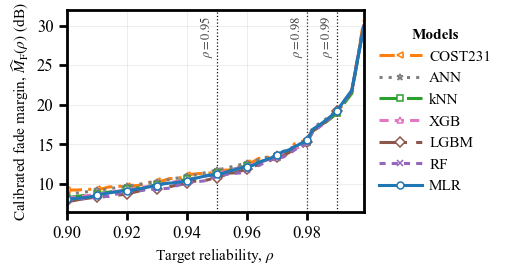

In [9]:
# Dense reliability plot.

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

FIGURES_DIR = Path("Figures")
FIGURES_DIR.mkdir(exist_ok=True)

legend_map = {
    "MLR": "MLR",
    "COST 231 MWM": "COST231",
    "KNN": "kNN",
    "RF": "RF",
    "LightGBM": "LGBM",
    "XGBoost": "XGB",
    "ANN": "ANN",
}

color_map = {
    "MLR": "#1f77b4",
    "COST 231 MWM": "#ff7f0e",
    "KNN": "#2ca02c",
    "RF": "#9467bd",
    "LightGBM": "#8c564b",
    "XGBoost": "#e377c2",
    "ANN": "#7f7f7f",
}

style_map = {
    "MLR": dict(ls="-", dashes=None, marker="o"),
    "COST 231 MWM": dict(ls="-.", dashes=(5, 2, 1, 2), marker="<"),
    "KNN": dict(ls="--", dashes=(6, 3), marker="s"),
    "RF": dict(ls=":", dashes=(2, 2), marker="x"),
    "LightGBM": dict(ls="-.", dashes=(9, 3, 2, 3), marker="D"),
    "XGBoost": dict(ls="--", dashes=(3, 2), marker="^"),
    "ANN": dict(ls="-", dashes=(1, 2), marker="*"),
}

available_models = [
    m for m in legend_map
    if m in MODEL_ORDER and m in dense_fm_df["model"].unique()
]

rank_reliability = dense_fm_df["target_reliability"].max()

rank_df = dense_fm_df[
    (dense_fm_df["model"].isin(available_models))
    & (dense_fm_df["target_reliability"] == rank_reliability)
]

dense_plot_models = sorted(
    available_models,
    key=lambda m: rank_df.loc[rank_df["model"] == m, "fm_sel"].min()
    if (rank_df["model"] == m).any()
    else float("-inf"),
    reverse=True,
)

tick_fontsize = 12
axis_labelsize = 11
legend_fontsize = 11

fig, ax = plt.subplots(figsize=(5.5, 2.5))

for fam in dense_plot_models:
    sub = dense_fm_df[dense_fm_df["model"] == fam].sort_values("target_reliability")
    st = style_map.get(fam, {})
    color = color_map.get(fam, None)

    ln, = ax.plot(sub["target_reliability"], sub["fm_sel"], linewidth=2.2, linestyle=st.get("ls", "-"), marker=st.get("marker", None), markevery=5, markersize=5.0, 
                  markerfacecolor="white", markeredgewidth=1.1, color=color, label=legend_map.get(fam, fam), zorder=2)

    ln.set_markeredgecolor(color if color is not None else ln.get_color())

    if st.get("dashes") is not None:
        ln.set_dashes(st["dashes"])

ax.set_xlabel(r"Target reliability, $\rho$", fontsize=axis_labelsize)
ax.set_ylabel(
    r"Calibrated fade margin, $\widehat{M}_{\mathrm{F}}(\rho)$ (dB)",
    fontsize=axis_labelsize,
)

ax.set_xlim(DENSE_RELIABILITY_GRID.min(), DENSE_RELIABILITY_GRID.max())

shown = dense_fm_df[dense_fm_df["model"].isin(dense_plot_models)]["fm_sel"]
pad = 0.06 * (shown.max() - shown.min())
ax.set_ylim(shown.min() - pad, shown.max() + pad)


# Thin reference lines for common reliability targets.
for x, label in [(0.95, r"$\rho=0.95$"), (0.98, r"$\rho=0.98$"),  (0.99, r"$\rho=0.99$"),]:
    ax.axvline(x, linestyle=":", linewidth=0.9, color="black", alpha=0.95, zorder=1)
    ax.text(x - 0.0005, 0.97, label, transform=ax.get_xaxis_transform(), rotation=90, fontsize=9, color="0.25", ha="right", va="top", zorder=4)

ax.tick_params(axis="both", labelsize=tick_fontsize)
ax.grid(True, which="both", linewidth=0.5, alpha=0.3, zorder=0)

leg = ax.legend(
    title="Models",
    loc="center left",
    bbox_to_anchor=(1.03, 0.5),
    ncol=1,
    fontsize=legend_fontsize,
    title_fontproperties={"weight": "bold", "size": legend_fontsize},
    frameon=False,
    handlelength=2.8,
    handletextpad=0.5,
    borderaxespad=0.0,
)

leg.set_zorder(10)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor("black")

ax.tick_params(which="both", width=2, length=6)

fig.subplots_adjust(left=0.16, right=0.70, top=0.96, bottom=0.15)

dense_fig_path = FIGURES_DIR / "fm_dense_reliability_tradeoff.png"
plt.savefig(dense_fig_path, dpi=600, bbox_inches="tight")
plt.show()

#### RF Tail Feature Importance

In [10]:
# Permutation importance for RF 99% tail events using row-level OOF residuals.
# This explains which covariates identify RF fade-margin failures with a time-heldout OOF fold.

FM_RESULTS_DIR = Path(globals().get("FM_RESULTS_DIR", "FM_Results"))
FIGURES_DIR = Path(globals().get("FIGURES_DIR", "Figures"))
FM_RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RF_FEATURES = ["distance", "frequency", "c_walls", "w_walls", "co2", "humidity", "pm25", "pressure", "temperature"]

RF_FEATURE_GROUPS = {
    "structural_geometry": ["distance", "c_walls", "w_walls"],
    "radio_channel": ["frequency"],
    "environmental": ["co2", "humidity", "pm25", "pressure", "temperature"],
}

RF_TAIL_P = 0.01

rf_oof_path = _first_existing(CANDIDATE_OOF_FILES["RF"])
rf_required_cols = ["resid_db", "fold", "time", *RF_FEATURES]
rf_optional_cols = ["row_id", "device_id"]
rf_usecols = rf_required_cols + rf_optional_cols

rf_oof_df = pd.read_csv(rf_oof_path, usecols=lambda c: c in rf_usecols).copy()
missing_rf_cols = sorted(set(rf_required_cols) - set(rf_oof_df.columns))
if missing_rf_cols:
    raise KeyError(f"RF OOF residual file is missing required columns: {missing_rf_cols}")

rf_oof_df = rf_oof_df.dropna(subset=rf_required_cols).copy()
rf_oof_df["time"] = pd.to_datetime(rf_oof_df["time"], utc=True, errors="coerce")
rf_oof_df["fold"] = pd.to_numeric(rf_oof_df["fold"], errors="coerce")
rf_oof_df = rf_oof_df.dropna(subset=["time", "fold"]).copy()
rf_oof_df["fold"] = rf_oof_df["fold"].astype(int)

if (rf_oof_df["fold"] < 0).any():
    raise ValueError("RF OOF residuals should contain validation folds only; found fold < 0.")

sort_cols = ["time"] + (["row_id"] if "row_id" in rf_oof_df.columns else [])
rf_oof_df = rf_oof_df.sort_values(sort_cols).reset_index(drop=True)

rf_fm99 = float(
    fm_table[
        (fm_table["model"] == "RF")
        & np.isclose(fm_table["p"].astype(float), RF_TAIL_P)
    ]["fm_sel"].iloc[0]
)

rf_oof_df["tail_event"] = (rf_oof_df["resid_db"] > rf_fm99).astype(int)

if rf_oof_df["tail_event"].nunique() < 2:
    raise ValueError("RF OOF tail-event target has one class only; cannot compute permutation importance.")

rf_tail_eval_fold = int(rf_oof_df["fold"].max())
rf_tail_train_folds = sorted(int(f) for f in rf_oof_df["fold"].unique() if int(f) < rf_tail_eval_fold)

if not rf_tail_train_folds:
    raise ValueError("Need at least one earlier OOF fold to train the RF tail-event diagnostic.")

rf_tail_train_all = rf_oof_df[rf_oof_df["fold"].isin(rf_tail_train_folds)].copy()
rf_tail_eval_df = rf_oof_df[rf_oof_df["fold"].eq(rf_tail_eval_fold)].copy()

rf_tail_train_end = rf_tail_train_all["time"].max()
rf_tail_eval_start = rf_tail_eval_df["time"].min()
if not (rf_tail_train_end < rf_tail_eval_start):
    raise ValueError(
        "RF tail-event diagnostic split is not time-ordered: "
        f"train max time={rf_tail_train_end}, eval min time={rf_tail_eval_start}."
    )

for split_name, split_df in {
    "train": rf_tail_train_all,
    "eval": rf_tail_eval_df,
}.items():
    if split_df["tail_event"].nunique() < 2:
        raise ValueError(f"RF OOF tail-event {split_name} split has one class only.")

rf_tail_pos = rf_tail_train_all[rf_tail_train_all["tail_event"] == 1]
rf_tail_neg = rf_tail_train_all[rf_tail_train_all["tail_event"] == 0]

neg_n = min(
    len(rf_tail_neg),
    max(50_000, min(200_000, 20 * len(rf_tail_pos))),
)

rf_tail_train_df = (
    pd.concat(
        [
            rf_tail_pos,
            rf_tail_neg.sample(n=neg_n, random_state=RANDOM_STATE),
        ],
        axis=0,
    )
    .sample(frac=1.0, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

X_train_tail = rf_tail_train_df[RF_FEATURES]
y_train_tail = rf_tail_train_df["tail_event"].to_numpy(dtype=np.int8)
X_eval_tail = rf_tail_eval_df[RF_FEATURES]
y_eval_tail = rf_tail_eval_df["tail_event"].to_numpy(dtype=np.int8)

rf_tail_split_summary = pd.DataFrame([
    {
        "train_folds": ",".join(map(str, rf_tail_train_folds)),
        "eval_fold": rf_tail_eval_fold,
        "train_source_rows": len(rf_tail_train_all),
        "train_model_rows": len(rf_tail_train_df),
        "train_tail_positives": int(rf_tail_train_df["tail_event"].sum()),
        "train_tail_rate_model_sample": float(rf_tail_train_df["tail_event"].mean()),
        "eval_rows": len(rf_tail_eval_df),
        "eval_tail_positives": int(rf_tail_eval_df["tail_event"].sum()),
        "eval_tail_rate": float(rf_tail_eval_df["tail_event"].mean()),
        "train_max_time": rf_tail_train_end,
        "eval_min_time": rf_tail_eval_start,
    }
])

rf_tail_split_summary_path = FM_RESULTS_DIR / "rf_tail_event_temporal_split_summary.csv"
rf_tail_split_summary.to_csv(rf_tail_split_summary_path, index=False)

tail_clf = HistGradientBoostingClassifier(
    max_iter=180,
    learning_rate=0.06,
    max_leaf_nodes=31,
    l2_regularization=0.05,
    random_state=RANDOM_STATE,
)

tail_clf.fit(X_train_tail, y_train_tail)

tail_scores = tail_clf.predict_proba(X_eval_tail)[:, 1]
tail_average_precision = average_precision_score(y_eval_tail, tail_scores)
tail_roc_auc = roc_auc_score(y_eval_tail, tail_scores)

tail_perm = permutation_importance(
    tail_clf,
    X_eval_tail,
    y_eval_tail,
    scoring="average_precision",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

importance_raw = np.maximum(tail_perm.importances_mean, 0.0)

if importance_raw.sum() > 0:
    importance_pct = 100.0 * importance_raw / importance_raw.sum()
else:
    importance_pct = np.full_like(importance_raw, np.nan)

rf_tail_importance_df = (
    pd.DataFrame({
        "feature": RF_FEATURES,
        "importance_mean_ap_drop": tail_perm.importances_mean,
        "importance_std_ap_drop": tail_perm.importances_std,
        "importance_pct": importance_pct,
    })
    .sort_values("importance_mean_ap_drop", ascending=False)
    .reset_index(drop=True)
)

group_rows = []
for group_name, group_features in RF_FEATURE_GROUPS.items():
    group_rows.append({
        "group": group_name,
        "features": ", ".join(group_features),
        "importance_pct": rf_tail_importance_df.loc[
            rf_tail_importance_df["feature"].isin(group_features),
            "importance_pct",
        ].sum(),
    })

rf_tail_importance_summary = pd.DataFrame(group_rows)

rf_importance_path = FM_RESULTS_DIR / "rf_tail_event_permutation_importance.csv"
rf_importance_summary_path = FM_RESULTS_DIR / "rf_tail_event_importance_group_summary.csv"

rf_tail_importance_df.to_csv(rf_importance_path, index=False)
rf_tail_importance_summary.to_csv(rf_importance_summary_path, index=False)

display(rf_tail_split_summary)
display(rf_tail_importance_df.round(4))
display(rf_tail_importance_summary.round(2))

top3 = rf_tail_importance_df.head(3)
top3_txt = ", ".join(
    f"{r.feature} ({r.importance_pct:.1f}%)"
    for r in top3.itertuples()
)

print(
    "RF OOF tail-event classifier: "
    f"train folds={rf_tail_train_folds}, eval fold={rf_tail_eval_fold}; "
    f"train source n={len(rf_tail_train_all):,}, train model n={len(rf_tail_train_df):,}, "
    f"train tail positives={int(rf_tail_train_df['tail_event'].sum()):,}; "
    f"eval n={len(rf_tail_eval_df):,}, "
    f"eval tail positives={int(rf_tail_eval_df['tail_event'].sum()):,} "
    f"({rf_tail_eval_df['tail_event'].mean():.3%}); "
    f"AP={tail_average_precision:.3f}, ROC-AUC={tail_roc_auc:.3f}."
)

print(f"Time-heldout RF tail drivers: {top3_txt}.")

for row in rf_tail_importance_summary.itertuples():
    print(f"{row.group}: {row.importance_pct:.1f}%")

print(f"Saved RF temporal split summary: {rf_tail_split_summary_path}")
print(f"Saved RF tail importance table: {rf_importance_path}")
print(f"Saved RF group summary table: {rf_importance_summary_path}")

,train_folds,eval_fold,train_source_rows,train_model_rows,train_tail_positives,train_tail_rate_model_sample,eval_rows,eval_tail_positives,eval_tail_rate,train_max_time,eval_min_time
0,"0,1,2,3",4,1418812,214043,14043,0.065608,354703,1007,0.002839,2025-06-04 02:08:07.049606+00:00,2025-06-04 02:08:15.683623+00:00


,feature,importance_mean_ap_drop,importance_std_ap_drop,importance_pct
0,distance,0.0006,0.0000,49.6873
1,temperature,0.0002,0.0000,18.5474
2,frequency,0.0002,0.0000,12.7046
3,c_walls,0.0001,0.0000,11.2042
4,humidity,0.0001,0.0001,7.8565
5,w_walls,-0.0000,0.0000,0.0000
6,co2,-0.0000,0.0000,0.0000
7,pm25,-0.0002,0.0000,0.0000
8,pressure,-0.0003,0.0001,0.0000


,group,features,importance_pct
0,structural_geometry,"distance, c_walls, w_walls",60.89
1,radio_channel,frequency,12.70
2,environmental,"co2, humidity, pm25, pressure, temperature",26.40


RF OOF tail-event classifier: train folds=[0, 1, 2, 3], eval fold=4; train source n=1,418,812, train model n=214,043, train tail positives=14,043; eval n=354,703, eval tail positives=1,007 (0.284%); AP=0.003, ROC-AUC=0.576.
Time-heldout RF tail drivers: distance (49.7%), temperature (18.5%), frequency (12.7%).
structural_geometry: 60.9%
radio_channel: 12.7%
environmental: 26.4%
Saved RF temporal split summary: FM_Results/rf_tail_event_temporal_split_summary.csv
Saved RF tail importance table: FM_Results/rf_tail_event_permutation_importance.csv
Saved RF group summary table: FM_Results/rf_tail_event_importance_group_summary.csv


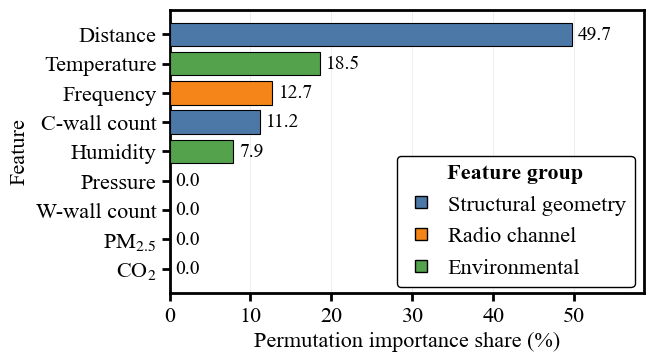

In [11]:
# RF tail-event permutation-importance plot.

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

FIGURES_DIR = Path("Figures")
FIGURES_DIR.mkdir(exist_ok=True)

FEATURE_LABELS = {
    "distance": "Distance",
    "frequency": "Frequency",
    "c_walls": "C-wall count",
    "w_walls": "W-wall count",
    "co2": "CO$_2$",
    "humidity": "Humidity",
    "pm25": "PM$_{2.5}$",
    "pressure": "Pressure",
    "temperature": "Temperature",
}

FEATURE_COLORS = {"structural_geometry": "#4C78A8", "radio_channel": "#F58518", "environmental": "#54A24B"}

feature_to_group = {}
for group_name, group_features in RF_FEATURE_GROUPS.items():
    for feature in group_features:
        feature_to_group[feature] = group_name

plot_df = rf_tail_importance_df.copy()
plot_df["feature_label"] = plot_df["feature"].map(FEATURE_LABELS).fillna(plot_df["feature"])
plot_df["group"] = plot_df["feature"].map(feature_to_group)
plot_df["color"] = plot_df["group"].map(FEATURE_COLORS).fillna("0.35")

plot_df = plot_df.sort_values("importance_pct", ascending=True)

tick_fontsize = 16
axis_labelsize = 16
legend_fontsize = 16
value_fontsize = 14

fig, ax = plt.subplots(figsize=(6.5, 3.5))

bars = ax.barh(plot_df["feature_label"], plot_df["importance_pct"], color=plot_df["color"], edgecolor="black", linewidth=0.8, zorder=3)

# Add plotted values at the front/end of each bar
xmax = plot_df["importance_pct"].max()
ax.set_xlim(0, xmax * 1.18)

for bar, value in zip(bars, plot_df["importance_pct"]):
    ax.text(
        value + xmax * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        ha="left",
        fontsize=value_fontsize,
        color="black",
        zorder=6,
    )

ax.set_xlabel("Permutation importance share (%)", fontsize=axis_labelsize)
ax.set_ylabel("Feature", fontsize=axis_labelsize)

ax.tick_params(axis="both", labelsize=tick_fontsize)
ax.grid(axis="x", which="both", linewidth=0.5, alpha=0.3, zorder=0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor("black")

ax.tick_params(which="both", width=2, length=6)

legend_handles = [plt.Line2D([0], [0], marker="s", color="none", markerfacecolor=FEATURE_COLORS["structural_geometry"], markeredgecolor="black", markersize=8, label="Structural geometry"),

                  plt.Line2D([0], [0], marker="s", color="none", markerfacecolor=FEATURE_COLORS["radio_channel"], markeredgecolor="black", markersize=8, label="Radio channel"),

                  plt.Line2D([0], [0], marker="s", color="none", markerfacecolor=FEATURE_COLORS["environmental"], markeredgecolor="black", markersize=8, label="Environmental")]

leg = ax.legend(
    handles=legend_handles,
    title="Feature group",
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    bbox_transform=ax.transAxes,
    ncol=1,
    fontsize=legend_fontsize,
    title_fontproperties={"weight": "bold", "size": legend_fontsize},
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
    handlelength=1.4,
    handletextpad=0.5,
    borderaxespad=0.0,
)

leg.set_zorder(100)
leg.get_frame().set_zorder(100)

fig.subplots_adjust(left=0.23, right=0.96, top=0.96, bottom=0.15)

rf_importance_fig_path = FIGURES_DIR / "rf_tail_event_permutation_importance.png"
plt.savefig(rf_importance_fig_path, dpi=600, bbox_inches="tight")
plt.show()

#### RF Held-Out Failure Events

In [12]:
# Characterize the residual-risk events that remain above the RF 99% fade margin.
FM_RESULTS_DIR = Path(globals().get("FM_RESULTS_DIR", "FM_Results"))
FM_RESULTS_DIR.mkdir(exist_ok=True)

rf_test_path = _first_existing(CANDIDATE_TEST_FILES["RF"])
rf_failure_cols = ["row_id", "time", "device_id", "resid_db", "PL_true", "PL_pred", *RF_FEATURES]
rf_test_df = pd.read_csv(rf_test_path, usecols=lambda c: c in rf_failure_cols).copy()
rf_test_df["time"] = pd.to_datetime(rf_test_df["time"], utc=True, errors="coerce")
rf_test_df = rf_test_df.sort_values(["device_id", "time", "row_id"]).reset_index(drop=True)

rf_test_df["rf_failure_99"] = rf_test_df["resid_db"] > rf_fm99
rf_failure_mask = rf_test_df["rf_failure_99"]
rf_failure_count = int(rf_failure_mask.sum())
rf_failure_rate = float(rf_failure_mask.mean())

rf_test_df["dt_min"] = rf_test_df.groupby("device_id")["time"].diff().dt.total_seconds() / 60.0
rf_test_df.loc[rf_test_df["dt_min"] <= 0, "dt_min"] = np.nan

rate_specs = {
    "temperature": "temperature_rate_c_per_min",
    "pm25": "pm25_rate_ugm3_per_min",
    "humidity": "humidity_rate_pct_per_min",
    "co2": "co2_rate_ppm_per_min",
    "pressure": "pressure_rate_per_min",
}
for col, rate_col in rate_specs.items():
    rf_test_df[rate_col] = rf_test_df.groupby("device_id")[col].diff() / rf_test_df["dt_min"]

rf_test_df["temp_drop_gt_2c_per_min"] = rf_test_df["temperature_rate_c_per_min"] <= -2.0
rf_test_df["pm25_spike_gt_50_per_min"] = rf_test_df["pm25_rate_ugm3_per_min"] >= 50.0
rf_test_df["any_fixed_transient"] = rf_test_df[[
    "temp_drop_gt_2c_per_min", "pm25_spike_gt_50_per_min"
]].any(axis=1)

temp_drop_thr = float(rf_test_df["temperature_rate_c_per_min"].quantile(0.05))
pm25_spike_thr = float(rf_test_df["pm25_rate_ugm3_per_min"].quantile(0.95))

rf_test_df["temp_drop_bottom5_rate"] = rf_test_df["temperature_rate_c_per_min"] <= temp_drop_thr
rf_test_df["pm25_spike_top5_rate"] = rf_test_df["pm25_rate_ugm3_per_min"] >= pm25_spike_thr
rf_test_df["any_adaptive_transient"] = rf_test_df[[
    "temp_drop_bottom5_rate", "pm25_spike_top5_rate"
]].any(axis=1)

condition_cols = [
    "temp_drop_gt_2c_per_min",
    "pm25_spike_gt_50_per_min",
    "any_fixed_transient",
    "temp_drop_bottom5_rate",
    "pm25_spike_top5_rate",
    "any_adaptive_transient",
]

condition_rows = []
for cond in condition_cols:
    all_share = float(rf_test_df[cond].mean())
    fail_share = float(rf_test_df.loc[rf_failure_mask, cond].mean()) if rf_failure_count else np.nan
    condition_rows.append({
        "condition": cond,
        "failure_count": int(rf_test_df.loc[rf_failure_mask, cond].sum()) if rf_failure_count else 0,
        "failure_share": fail_share,
        "all_test_share": all_share,
        "enrichment_vs_all": fail_share / all_share if all_share > 0 and rf_failure_count else np.nan,
    })

rf_failure_transient_summary = pd.DataFrame(condition_rows)
rf_failure_transient_summary_path = FM_RESULTS_DIR / "rf_failure_transient_summary.csv"
rf_failure_transient_summary.to_csv(rf_failure_transient_summary_path, index=False)

summary_features = RF_FEATURES + list(rate_specs.values())
feature_rows = []
for col in summary_features:
    all_vals = rf_test_df[col].dropna()
    fail_vals = rf_test_df.loc[rf_failure_mask, col].dropna()
    feature_rows.append({
        "feature": col,
        "all_median": float(all_vals.median()) if len(all_vals) else np.nan,
        "failure_median": float(fail_vals.median()) if len(fail_vals) else np.nan,
        "failure_minus_all_median": float(fail_vals.median() - all_vals.median()) if len(all_vals) and len(fail_vals) else np.nan,
        "failure_q25": float(fail_vals.quantile(0.25)) if len(fail_vals) else np.nan,
        "failure_q75": float(fail_vals.quantile(0.75)) if len(fail_vals) else np.nan,
    })

rf_failure_feature_summary = pd.DataFrame(feature_rows)
rf_failure_feature_summary_path = FM_RESULTS_DIR / "rf_failure_feature_summary.csv"
rf_failure_feature_summary.to_csv(rf_failure_feature_summary_path, index=False)

rf_failure_device_summary = (
    rf_test_df.groupby("device_id", dropna=False)["rf_failure_99"]
    .agg(test_rows="size", failure_count="sum", outage_rate="mean")
    .reset_index()
    .sort_values("outage_rate", ascending=False)
)
rf_failure_device_summary_path = FM_RESULTS_DIR / "rf_failure_device_summary.csv"
rf_failure_device_summary.to_csv(rf_failure_device_summary_path, index=False)

rf_failure_events_path = FM_RESULTS_DIR / "rf_heldout_failure_events.csv"
failure_export_cols = [
    "row_id", "time", "device_id", "resid_db", "PL_true", "PL_pred",
    *RF_FEATURES, *list(rate_specs.values()), *condition_cols,
]
rf_test_df.loc[rf_failure_mask, failure_export_cols].to_csv(rf_failure_events_path, index=False)

display(rf_failure_transient_summary.round(4))
display(rf_failure_feature_summary.sort_values("failure_minus_all_median", key=lambda s: s.abs(), ascending=False).round(4))
display(rf_failure_device_summary.round(4))

fixed_share = float(rf_failure_transient_summary.loc[rf_failure_transient_summary["condition"] == "any_fixed_transient", "failure_share"].iloc[0])
adaptive_share = float(rf_failure_transient_summary.loc[rf_failure_transient_summary["condition"] == "any_adaptive_transient", "failure_share"].iloc[0])
print(
    f"RF held-out residual-risk events at 99% target: {rf_failure_count:,}/{len(rf_test_df):,} "
    f"packets exceed FM={rf_fm99:.2f} dB (outage={rf_failure_rate:.3%})."
)
print(
    "Fixed-threshold transient share among RF failures: "
    f"{fixed_share:.1%}; data-adaptive transient share: {adaptive_share:.1%}."
)
print(
    "Adaptive thresholds used: "
    f"temperature rate <= {temp_drop_thr:.3f} C/min, "
    f"PM2.5 rate >= {pm25_spike_thr:.3f} ug/m^3/min."
)
print(f"Saved RF failure events: {rf_failure_events_path}")
print(f"Saved RF failure summaries: {rf_failure_transient_summary_path}, {rf_failure_feature_summary_path}, {rf_failure_device_summary_path}")

,condition,failure_count,failure_share,all_test_share,enrichment_vs_all
0,temp_drop_gt_2c_per_min,0,0.0000,0.0000,NaN
1,pm25_spike_gt_50_per_min,0,0.0000,0.0000,0.0000
2,any_fixed_transient,0,0.0000,0.0000,0.0000
3,temp_drop_bottom5_rate,57,0.0517,0.0500,1.0345
4,pm25_spike_top5_rate,39,0.0354,0.0500,0.7078
5,any_adaptive_transient,94,0.0853,0.0972,0.8775


,feature,all_median,failure_median,failure_minus_all_median,failure_q25,failure_q75
0,distance,23.00,10.000,-13.000,8.0000,23.0000
4,co2,456.00,460.000,4.000,443.0000,499.0000
3,w_walls,2.00,0.000,-2.000,0.0000,2.0000
8,temperature,26.42,28.415,1.995,27.4500,28.6200
7,pressure,977.76,978.385,0.625,973.2900,980.7000
6,pm25,1.19,0.890,-0.300,0.5800,1.5800
5,humidity,40.32,40.370,0.050,36.2300,42.6375
10,pm25_rate_ugm3_per_min,0.00,-0.010,-0.010,-0.1499,0.1299
2,c_walls,0.00,0.000,0.000,0.0000,1.0000
1,frequency,867.90,867.900,0.000,867.7000,868.3000


,device_id,test_rows,failure_count,outage_rate
1,ED1,88573,498,0.0056
4,ED4,88648,255,0.0029
0,ED0,89116,232,0.0026
2,ED2,89123,116,0.0013
5,ED5,89380,1,0.0000
3,ED3,87215,0,0.0000


RF held-out residual-risk events at 99% target: 1,102/532,055 packets exceed FM=19.16 dB (outage=0.207%).
Fixed-threshold transient share among RF failures: 0.0%; data-adaptive transient share: 8.5%.
Adaptive thresholds used: temperature rate <= -0.030 C/min, PM2.5 rate >= 0.540 ug/m^3/min.
Saved RF failure events: FM_Results/rf_heldout_failure_events.csv
Saved RF failure summaries: FM_Results/rf_failure_transient_summary.csv, FM_Results/rf_failure_feature_summary.csv, FM_Results/rf_failure_device_summary.csv


#### ADR Translation from Measured Margin Savings

In [13]:
# Translate measured dB savings into approximate LoRaWAN SF and ToA implications.
# This is a physical-layer calculation, not a packet-level ADR simulator.
FM_RESULTS_DIR = Path(globals().get("FM_RESULTS_DIR", "FM_Results"))
FM_RESULTS_DIR.mkdir(exist_ok=True)

ADR_P = 0.01
SF_STEP_DB = 2.5
MAX_LORAWAN_SF_STEPS = 5.0  # SF12 down to SF7.
ADR_BASELINE_MODEL = "MLR"

def fm_table_value(model_name, p=ADR_P):
    rows = fm_table[(fm_table["model"] == model_name) & np.isclose(fm_table["p"].astype(float), p)]
    if rows.empty:
        raise KeyError(f"No fm_table row for {model_name} at p={p}")
    return float(rows["fm_sel"].iloc[0])

baseline_fm = fm_table_value(ADR_BASELINE_MODEL, ADR_P)
adr_rows = []
for fam in MODEL_ORDER:
    fm_used = fm_table_value(fam, ADR_P)
    saving_db = baseline_fm - fm_used
    theoretical_sf_steps = saving_db / SF_STEP_DB
    capped_sf_steps = float(np.clip(theoretical_sf_steps, 0.0, MAX_LORAWAN_SF_STEPS))
    full_sf_steps = int(np.floor(capped_sf_steps + 1e-12))
    toa_ratio_fractional = 2.0 ** (-capped_sf_steps)
    adr_rows.append({
        "model": fam,
        "fm_99_db": fm_used,
        "saving_vs_mlr_db": saving_db,
        "sf_steps_theoretical": theoretical_sf_steps,
        "sf_steps_capped_to_sf12_sf7": capped_sf_steps,
        "full_integer_sf_steps": full_sf_steps,
        "example_from_sf12_to_sf": int(max(7, 12 - full_sf_steps)),
        "toa_ratio_after_fractional_steps": toa_ratio_fractional,
        "toa_reduction_pct_after_fractional_steps": 100.0 * (1.0 - toa_ratio_fractional),
    })

adr_translation_df = pd.DataFrame(adr_rows).sort_values("saving_vs_mlr_db", ascending=False)
adr_translation_path = FM_RESULTS_DIR / "adr_translation_from_measured_margin_savings.csv"
adr_translation_df.to_csv(adr_translation_path, index=False)

display(adr_translation_df.round(3))

if "RF" in set(MODEL_ORDER):
    rf_adr = adr_translation_df[adr_translation_df["model"] == "RF"].iloc[0]
    print(
        "Claim-ready ADR translation for RF vs MLR at 99% reliability: "
        f"saving={rf_adr.saving_vs_mlr_db:.2f} dB, "
        f"SF-step equivalent={rf_adr.sf_steps_theoretical:.2f}, "
        f"integer example SF12 -> SF{int(rf_adr.example_from_sf12_to_sf)}, "
        f"approximate ToA reduction={rf_adr.toa_reduction_pct_after_fractional_steps:.1f}%."
    )

print(f"Saved ADR translation table: {adr_translation_path}")

,model,fm_99_db,saving_vs_mlr_db,sf_steps_theoretical,sf_steps_capped_to_sf12_sf7,full_integer_sf_steps,example_from_sf12_to_sf,toa_ratio_after_fractional_steps,toa_reduction_pct_after_fractional_steps
1,COST 231 MWM,18.930,0.292,0.117,0.117,0,12,0.922,7.783
2,KNN,18.944,0.278,0.111,0.111,0,12,0.926,7.428
4,LightGBM,19.155,0.067,0.027,0.027,0,12,0.982,1.842
3,RF,19.162,0.060,0.024,0.024,0,12,0.983,1.658
5,XGBoost,19.208,0.014,0.006,0.006,0,12,0.996,0.383
0,MLR,19.222,0.000,0.000,0.000,0,12,1.000,0.000
6,ANN,19.330,-0.108,-0.043,0.000,0,12,1.000,0.000


Claim-ready ADR translation for RF vs MLR at 99% reliability: saving=0.06 dB, SF-step equivalent=0.02, integer example SF12 -> SF12, approximate ToA reduction=1.7%.
Saved ADR translation table: FM_Results/adr_translation_from_measured_margin_savings.csv


#### Plot: PDR vs FM — overlay for COST 231 MWM / MLR / kNN / RF / LightGBM / XGBoost / ANN


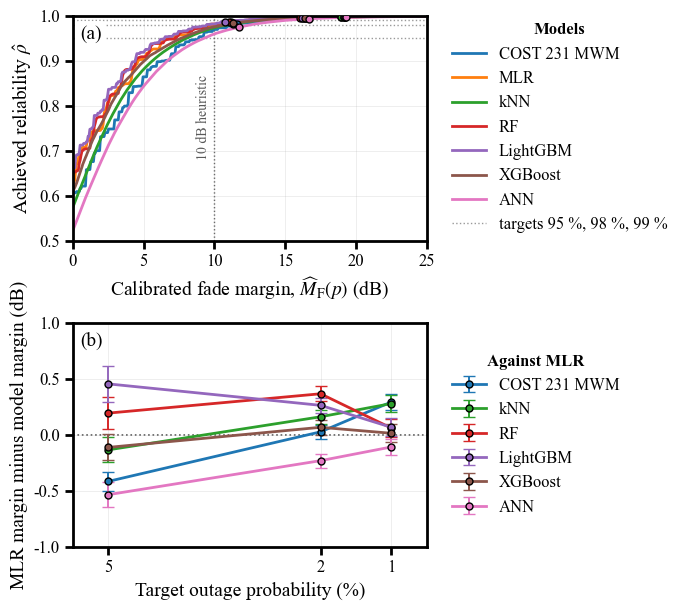

In [14]:
# (a) Reliability reached on the hold-out set against the fade margin, one curve per model. The calibrated margins at the
#     three targets are drawn where they land on the hold-out curve: x is the margin with its 95 % interval, y the reliability
#     it achieves. The dotted horizontals are the targets, so the gap between a marker and its target is the over- or
#     under-coverage.
# (b) The MLR margin minus each other model's margin at each target (positive = the model needs less margin than MLR). The two
#     margins come from independent bootstraps, so the 95 % interval of the difference uses the root sum of squares of the two
#     standard errors, each taken as the half-width of its 95 % interval divided by 1.96.
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

legend_map = {"COST 231 MWM": "COST 231 MWM", "MLR": "MLR", "KNN": "kNN", "RF": "RF", "LightGBM": "LightGBM", "XGBoost": "XGBoost", "ANN": "ANN"}
BASELINE = "MLR"
targets = sorted(P_GRID, reverse=True)

def reliability_curve(eps, grid):
    eps = np.sort(np.asarray(eps, float))
    return np.searchsorted(eps, grid, side="right") / eps.size

def margin_and_se(fam, p):
    r = fm_table[(fm_table["model"] == fam) & np.isclose(fm_table["p"], p)].iloc[0]
    return float(r["fm_sel"]), float(r["fm_sel_hi"] - r["fm_sel_lo"]) / (2 * 1.96)

models = [m for m in legend_map if m in test_residuals and m in set(fm_table["model"])]
fm_max = 5 * np.ceil(max(np.percentile(test_residuals[m], 99.9) for m in models) / 5)
grid = np.linspace(0.0, fm_max, 400)
curves = {m: reliability_curve(test_residuals[m], grid) for m in models}
diffs = pd.DataFrame([{"model": m, "p": p,
                       "diff": margin_and_se(BASELINE, p)[0] - margin_and_se(m, p)[0],
                       "se": np.hypot(margin_and_se(BASELINE, p)[1], margin_and_se(m, p)[1])}
                      for m in models if m != BASELINE for p in targets])

fig, (axA, axB) = plt.subplots(2, 1, figsize=(7.0, 6.2))

colors = {}
for m in models:
    line, = axA.plot(grid, curves[m], linewidth=2, label=legend_map[m])
    colors[m] = line.get_color()
for k, p in enumerate(targets):
    axA.axhline(1 - p, linestyle=":", linewidth=1, color="0.6", zorder=0,
                label="targets " + ", ".join(f"{100 * (1 - q):g} %" for q in targets) if k == 0 else None)
axA.axvline(HEURISTIC_FM_DB, linestyle=":", linewidth=1, color="0.35", zorder=0)
axA.text(HEURISTIC_FM_DB - 0.3, 0.55, f"{HEURISTIC_FM_DB:g} dB heuristic", transform=axA.get_xaxis_transform(),
         fontsize=10, color="0.35", ha="right", va="center", rotation=90)
for m in models:
    rows = validation_df[(validation_df["model"] == m) & validation_df["p_target"].notna()]
    xerr = np.clip(np.vstack([rows["FM_used"] - rows["FM_lo"], rows["FM_hi"] - rows["FM_used"]]), 0, None)
    axA.errorbar(rows["FM_used"], rows["achieved_reliability"], xerr=xerr, fmt="o", markersize=5, color=colors[m],
                 markeredgecolor="black", elinewidth=2, zorder=5)
axA.set_xlim(0, fm_max)
axA.set_ylim(np.floor(20 * min(c[0] for c in curves.values())) / 20, 1.0)
axA.set_xlabel(r"Calibrated fade margin, $\widehat{M}_{\mathrm{F}}(p)$ (dB)", fontsize=14)
axA.set_ylabel(r"Achieved reliability $\hat{\rho}$", fontsize=14)
axA.legend(title="Models", loc="center left", bbox_to_anchor=(1.03, 0.5), fontsize=12, title_fontproperties={"weight": "bold", "size": 12}, frameon=False)

for m in models:
    d = diffs[diffs["model"] == m]
    if d.empty:
        continue
    axB.errorbar(100 * d["p"], d["diff"], yerr=1.96 * d["se"], fmt="o-", markersize=5, color=colors[m], markeredgecolor="black",
                 linewidth=2, elinewidth=1.4, capsize=4, label=legend_map[m])
axB.axhline(0, linestyle=":", linewidth=1.2, color="0.35", zorder=0)
limit = max(1.0, np.ceil(2 * (diffs["diff"].abs() + 1.96 * diffs["se"]).max()) / 2)   # at least ±1 dB, never clipping an interval
axB.set_ylim(-limit, limit)
axB.set_xticks([100 * p for p in targets])
axB.set_xlim(100 * max(targets) + 0.5, 100 * min(targets) - 0.5)
axB.set_xlabel("Target outage probability (%)", fontsize=14)
axB.set_ylabel(f"{legend_map[BASELINE]} margin minus model margin (dB)", fontsize=14)
axB.legend(title=f"Against {legend_map[BASELINE]}", loc="center left", bbox_to_anchor=(1.03, 0.5), fontsize=12, title_fontproperties={"weight": "bold", "size": 12}, frameon=False)

for ax, tag in ((axA, "(a)"), (axB, "(b)")):
    ax.grid(True, linewidth=0.5, alpha=0.3)
    ax.tick_params(axis="both", labelsize=12, width=2, length=6)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.text(0.02, 0.96, tag, transform=ax.transAxes, ha="left", va="top", fontsize=14, bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none"))
fig.tight_layout()
plt.savefig("Figures/pdr_fade_margin_and_reduction_wide.png", dpi=300, bbox_inches="tight")
plt.show()


#### Display Summaries + Paper Snippet

In [15]:
# Display tables
display(fm_table)
display(validation_df)

def paper_snippet(model_name, p=0.01):
    sub = fm_table[(fm_table["model"] == model_name) & (fm_table["p"] == p)]
    if sub.empty:
        return f"[{model_name}] No FM row for p={p}."
    sub = sub.iloc[0]
    val = validation_df[(validation_df["model"] == model_name) & (validation_df["p_target"] == p)]
    if val.empty:
        return f"[{model_name}] No validation row for p={p}."
    val = val.iloc[0]
    fm = sub["fm_sel"]; lo = sub["fm_sel_lo"]; hi = sub["fm_sel_hi"]; est = sub["selected"]
    ach_p = val["achieved_outage"]; ach_pdr = val["achieved_reliability"]
    return (
        f"FM calibration for {model_name}: For p={p:.2%}, we obtain FM{int((1-p)*100)} = {fm:.2f} dB "
        f"[95% CI: {lo:.2f}, {hi:.2f}] using {est}. On held-out test, achieved outage "
        f"is {ach_p:.2%} (PDR={ach_pdr:.2%})."
    )

for fam in MODEL_ORDER:
    if fam in fm_table["model"].unique():
        print(paper_snippet(fam, p=0.01))

,model,p,block_len,fm_emp,fm_emp_lo,fm_emp_hi,param_name,fm_param,param_lo,param_hi,param_aic,param_bic,selected,fm_sel,fm_sel_lo,fm_sel_hi,estimator_note
0,MLR,0.01,25,18.242473,18.127587,18.566564,gmm(K=3),19.221891,19.168865,19.280021,1.155294e+07,1.155304e+07,gmm-tail,19.221891,19.168865,19.280021,gmm tail (K=3; parametric bootstrap CI)
1,MLR,0.02,25,15.474985,15.273424,15.644997,gmm(K=3),16.436112,16.390719,16.481561,1.155294e+07,1.155304e+07,gmm-tail,16.436112,16.390719,16.481561,gmm tail (K=3; parametric bootstrap CI)
2,MLR,0.05,25,11.194511,11.122591,11.261288,gmm(K=3),11.828746,11.792771,11.864609,1.155294e+07,1.155304e+07,empirical,11.194511,11.122591,11.261288,empirical quantile (BC bootstrap)
3,COST 231 MWM,0.01,25,18.605186,17.822723,18.641034,gmm(K=3),18.929635,18.882435,18.981021,1.201169e+07,1.201179e+07,gmm-tail,18.929635,18.882435,18.981021,gmm tail (K=3; parametric bootstrap CI)
4,COST 231 MWM,0.02,25,15.611192,15.469353,15.637029,gmm(K=3),16.409554,16.369237,16.448566,1.201169e+07,1.201179e+07,gmm-tail,16.409554,16.369237,16.448566,gmm tail (K=3; parametric bootstrap CI)
5,COST 231 MWM,0.05,25,11.609190,11.543569,11.640820,gmm(K=3),12.382451,12.351896,12.414608,1.201169e+07,1.201179e+07,empirical,11.609190,11.543569,11.640820,empirical quantile (BC bootstrap)
6,KNN,0.01,25,18.265181,18.106694,18.420800,gmm(K=3),18.943527,18.891495,18.999337,1.170175e+07,1.170185e+07,gmm-tail,18.943527,18.891495,18.999337,gmm tail (K=3; parametric bootstrap CI)
7,KNN,0.02,25,15.236382,15.096621,15.374670,gmm(K=3),16.275491,16.230807,16.320765,1.170175e+07,1.170185e+07,gmm-tail,16.275491,16.230807,16.320765,gmm tail (K=3; parametric bootstrap CI)
8,KNN,0.05,25,11.328396,11.245802,11.420512,gmm(K=3),11.957460,11.923933,11.990892,1.170175e+07,1.170185e+07,empirical,11.328396,11.245802,11.420512,empirical quantile (BC bootstrap)
9,RF,0.01,25,18.167985,17.665268,18.295478,gmm(K=3),19.161605,19.105840,19.221363,1.143863e+07,1.143873e+07,gmm-tail,19.161605,19.105840,19.221363,gmm tail (K=3; parametric bootstrap CI)


,model,p_target,FM_used,FM_lo,FM_hi,achieved_outage,achieved_reliability,estimator
0,MLR,0.01,19.221891,19.168865,19.280021,0.001940,0.998060,gmm-tail
1,MLR,0.02,16.436112,16.390719,16.481561,0.003554,0.996446,gmm-tail
2,MLR,0.05,11.194511,11.122591,11.261288,0.013104,0.986896,empirical
3,MLR,NaN,10.000000,NaN,NaN,0.023484,0.976516,Heuristic (10.0 dB)
4,COST 231 MWM,0.01,18.929635,18.882435,18.981021,0.002329,0.997671,gmm-tail
5,COST 231 MWM,0.02,16.409554,16.369237,16.448566,0.004456,0.995544,gmm-tail
6,COST 231 MWM,0.05,11.609190,11.543569,11.640820,0.017002,0.982998,empirical
7,COST 231 MWM,NaN,10.000000,NaN,NaN,0.029929,0.970071,Heuristic (10.0 dB)
8,KNN,0.01,18.943527,18.891495,18.999337,0.002167,0.997833,gmm-tail
9,KNN,0.02,16.275491,16.230807,16.320765,0.003904,0.996096,gmm-tail


FM calibration for MLR: For p=1.00%, we obtain FM99 = 19.22 dB [95% CI: 19.17, 19.28] using gmm-tail. On held-out test, achieved outage is 0.19% (PDR=99.81%).
FM calibration for COST 231 MWM: For p=1.00%, we obtain FM99 = 18.93 dB [95% CI: 18.88, 18.98] using gmm-tail. On held-out test, achieved outage is 0.23% (PDR=99.77%).
FM calibration for KNN: For p=1.00%, we obtain FM99 = 18.94 dB [95% CI: 18.89, 19.00] using gmm-tail. On held-out test, achieved outage is 0.22% (PDR=99.78%).
FM calibration for RF: For p=1.00%, we obtain FM99 = 19.16 dB [95% CI: 19.11, 19.22] using gmm-tail. On held-out test, achieved outage is 0.21% (PDR=99.79%).
FM calibration for LightGBM: For p=1.00%, we obtain FM99 = 19.15 dB [95% CI: 19.10, 19.21] using gmm-tail. On held-out test, achieved outage is 0.17% (PDR=99.83%).
FM calibration for XGBoost: For p=1.00%, we obtain FM99 = 19.21 dB [95% CI: 19.15, 19.27] using gmm-tail. On held-out test, achieved outage is 0.23% (PDR=99.77%).
FM calibration for ANN: For p